In [7]:
import os
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

In [8]:
# Specify file name
# (I'll select a random file from a specified data set)

# Specify where all the data set folders (i.e. DS1) are, here saved into "essp_dir" variable
essp_dir = '/work2/lbuc/data/ESSP4/ESSP4'

# Specify data set number
dset_num = 1

# Select a file at random from all files in the data set
file_list = glob(os.path.join(essp_dir,f'DS{dset_num}','Spectra',f'DS{dset_num}*.fits'))
file_name = np.random.choice(file_list)

In [21]:
# Use one order, as in the earlier code.
nord = 161-100 # for example; set this variable as in your main code if defined elsewhere
# nord = 161-96 # for example; set this variable as in your main code if defined elsewhere

In [41]:
# Load first file
inst = 'neid'
files = sorted(glob(os.path.join(essp_dir, f'DS{dset_num}','Spectra',f'DS{dset_num}*_{inst}.fits')))

# Load first file
hdus1 = fits.open(files[0])
wave = hdus1['wavelength'].data.copy()
spec1 = hdus1['flux'].data.copy()
cont1 = hdus1['continuum'].data.copy()
hdus1.close()

# Load second file
hdus2 = fits.open(files[1])
spec2 = hdus2['flux'].data.copy()
cont2 = hdus2['continuum'].data.copy()
hdus2.close()

# normalize by continuum
wave_ord = wave[nord]
spec1_ord = spec1[nord] / cont1[nord]
spec2_ord = spec2[nord] / cont2[nord]
wave_ord = np.log10(wave_ord * 1e-10)

nan_idx1 = np.where(np.isnan(spec1_ord))[0]
nan_idx2 = np.where(np.isnan(spec2_ord))[0]
nan_idx = np.union1d(nan_idx1, nan_idx2)
spec1_ord = np.delete(spec1_ord, nan_idx)
spec2_ord = np.delete(spec2_ord, nan_idx)
wave_ord = np.delete(wave_ord, nan_idx)


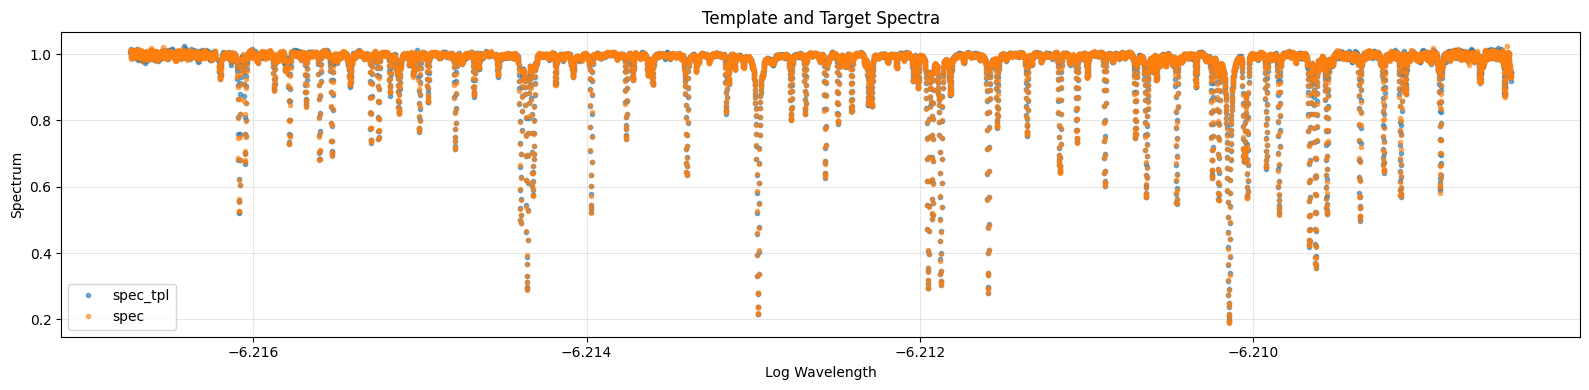

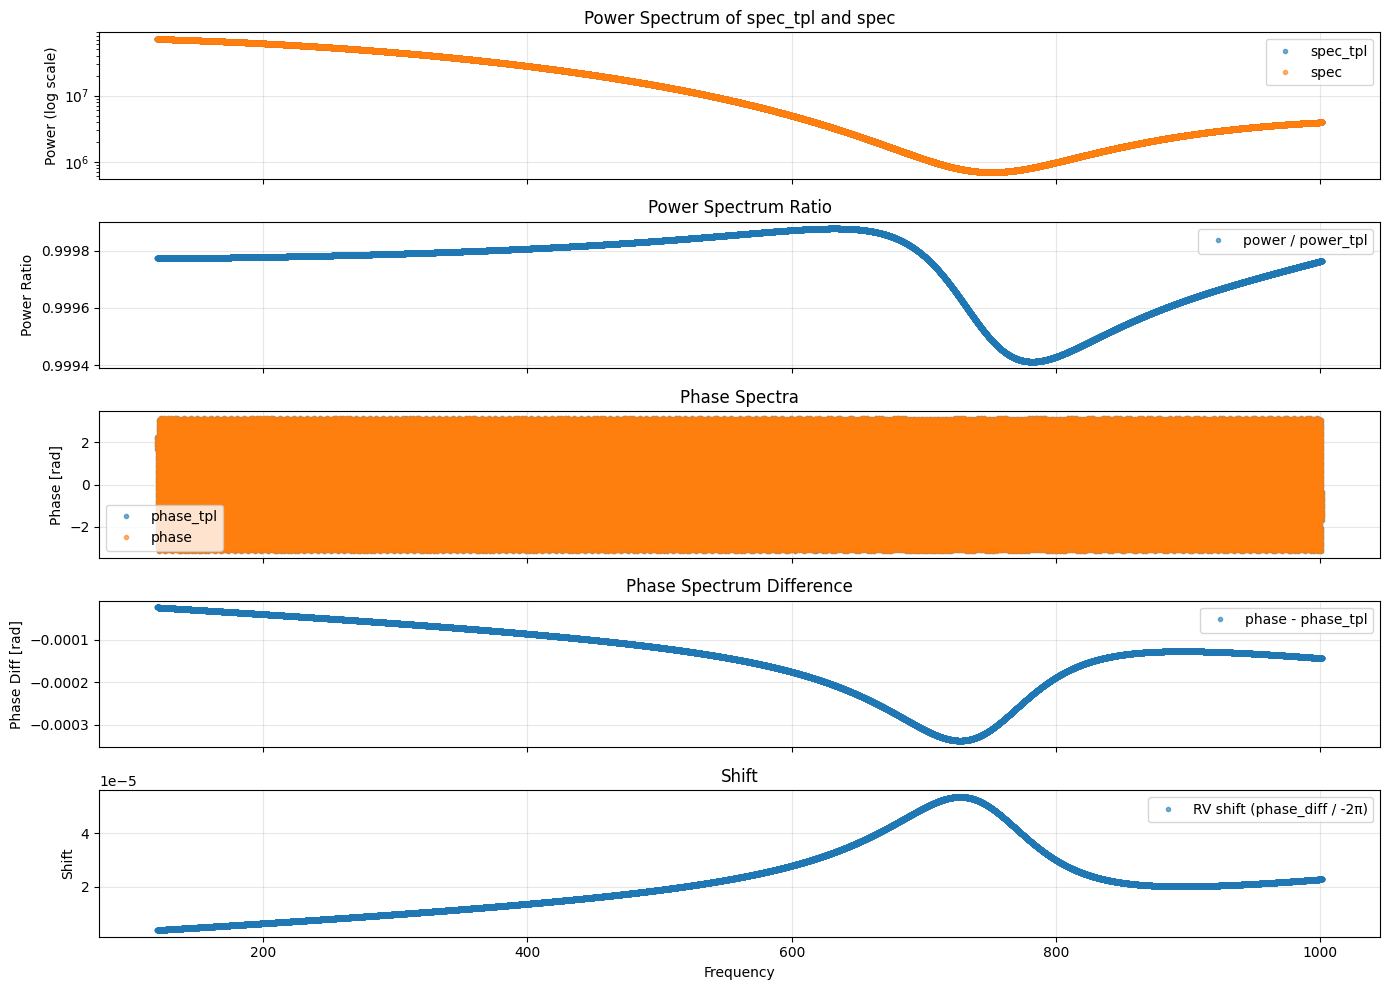

In [42]:
import sys
import importlib.util

# Import FIESTA_III/FIESTA-III.py as a module
spec = importlib.util.spec_from_file_location("FIESTA_III_module", "/work2/lbuc/jzhao/PyORBIT_ESSP/FIESTA_III/FIESTA-III.py")
FIESTA_III_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(FIESTA_III_module)
FIESTA_III = FIESTA_III_module.FIESTA_III

results = FIESTA_III(wave_ord, spec1_ord, spec2_ord, 
                    freq_max=1001, n_freq=50001,
                    plot_template=True, 
                    plot_comparison=True)
# plot in the same figure the single order for all the observations (so if 100 observations then plot 100 in one figure) - plot alll 1st order f.e. for all observations in one figure

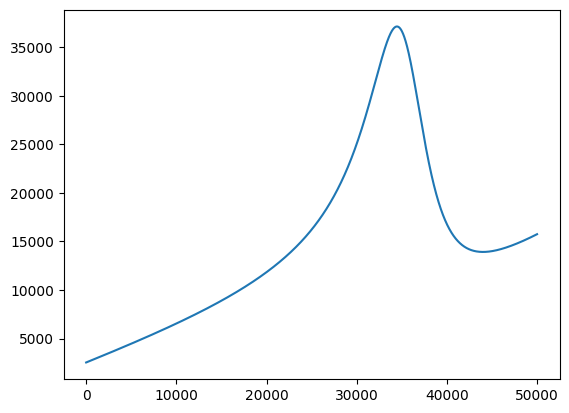

In [43]:
plt.plot((10**results['shift_spectrum']-1)*3e8)


In [40]:
wave_ord

array([-6.21673697, -6.21673578, -6.2167346 , ..., -6.20845488,
       -6.20845426, -6.20845364])